# Meta Model

## Purged Validation

- **Purpose:** Apply `purged_validation.py`'s `PurgedKFold` directly to the development partition.
- **Settings:** `cv=5` contiguous folds; `pct_embargo=0.01`; `random_state=42`; labels = {0, 1}; sealed chronological holdout.
- **Data:** Use development meta features, action labels, sample weights, and event information intervals.
- **Findings:**
- **Decision:** Purge overlapping intervals, exclude holdout from every fold, and maximize weighted F1 with weighted log loss used for ties.

In [1]:
from pathlib import Path

from IPython import get_ipython

get_ipython().run_line_magic("matplotlib", "inline")

import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parents[2]

from src.modeling.purged_validation import index_events
from src.modeling.purged_validation import PurgedKFold
from src.modeling.model_workflow import (
    build_model_evaluation_table,
    build_meta_model_frame,
    compute_stage_importance,
    finalize_meta_model,
    get_meta_feature_columns,
    plot_feature_importance,
    plot_learning_curves,
    plot_model_evaluation,
    run_model_selection_workflow,
)
from src.preprocessing.market_data import ResearchPaths

RANDOM_STATE = 42
CV_SPLITS = 5
PCT_EMBARGO = 0.01
TRAIN_SIZES = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
PERIOD = "2025-02-01_2025-12-31"
PARAMETER_GRIDS = {
    "boosting": {
        "model__n_estimators": [100, 200],
        "model__estimator__max_depth": [2, 5],
        "model__learning_rate": [0.03, 0.1],
    },
    "bagging": {
        "model__n_estimators": [100, 200],
        "model__estimator__max_depth": [2, 5],
        "model__max_samples": [0.4, 0.8],
        "model__max_features": [0.4, 0.8],
    },
    "random_forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [2, 5],
        "model__max_samples": [0.4, 0.8],
        "model__max_features": [0.1, 0.2],
    },
}
paths = ResearchPaths(PROJECT_ROOT, model_kind="sentiment", period=PERIOD)
event_path = paths.event("model")
artifact_dir = PROJECT_ROOT / "data/modeling/sentiment"
artifact_dir.mkdir(parents=True, exist_ok=True)

events = index_events(pd.read_parquet(event_path))
split_manifest = pd.read_parquet(artifact_dir / "split_manifest.parquet")
primary_predictions = index_events(pd.read_parquet(artifact_dir / "primary_predictions.parquet"))

development_primary = primary_predictions[
    primary_predictions["partition"].eq("development")
]
manifest_development = pd.MultiIndex.from_frame(split_manifest.loc[
    split_manifest["partition"].eq("development"), ["symbol", "event_start"]
])
if set(development_primary.index) != set(manifest_development):
    raise ValueError("Primary OOF rows must match the fixed development partition")

development_events = events.loc[development_primary.index]
primary_oof_contract = development_primary.rename(columns={
    "primary_side": "prediction",
    "primary_probability": "probability",
})
meta_development = build_meta_model_frame(
    development_events,
    primary_oof_contract[["prediction", "probability", "prediction_source"]],
)
meta_features = get_meta_feature_columns(meta_development, model_kind="sentiment")

X_development = meta_development[meta_features]
y_development = meta_development["meta_label"].astype("int8")
w_development = meta_development["sample_weight"].astype("float64")
t1_development = meta_development["event_end"]
CLASS_LABELS = [0, 1]
STAGE_SCORING = "f1"

cv = PurgedKFold(CV_SPLITS, t1=t1_development, pct_embargo=PCT_EMBARGO)
fold_rows = []
for fold, (train, test) in enumerate(cv.split(X_development)):
    fold_rows.append({
        "fold": fold,
        "train_events": len(train),
        "test_events": len(test),
        "test_start": t1_development.index.get_level_values("event_start")[test].min(),
        "test_end": t1_development.iloc[test].max(),
    })

display(pd.DataFrame(fold_rows).set_index("fold"))
display(pd.Series({
    "development_events": len(meta_development),
    "act_labels": int(y_development.sum()),
    "pass_labels": int((1 - y_development).sum()),
    "features": len(meta_features),
}, name="value").to_frame())

,train_events,test_events,test_start,test_end
fold,,,,
0,11344,2882,2025-02-03 14:30:00.009395+00:00,2025-04-02 16:54:06.660953+00:00
1,11027,2882,2025-04-02 14:13:38.147152+00:00,2025-05-06 18:38:13.769528+00:00
2,11290,2881,2025-05-02 13:30:03.066935+00:00,2025-07-10 16:38:14.868445+00:00
3,11335,2881,2025-07-10 14:37:39.034456+00:00,2025-09-03 17:45:21.507708+00:00
4,11515,2881,2025-09-03 13:30:00.864600+00:00,2025-10-24 13:50:57.771170+00:00


,value
development_events,14407
act_labels,7133
pass_labels,7274
features,52


## Ensemble Methods

- **Purpose:** Compare all AdaBoost, Bagging, and Random Forest configurations and select the best candidate per family and overall.
- **Settings:** Notebook-owned grids: 27 AdaBoost, 81 Bagging, 81 RF configurations; max_depth=[2, 5, 10] for all families; library-default leaf size; AdaBoost class_weight=None, Bagging class_weight=balanced, RF class_weight=balanced_subsample; entropy trees; cv=5; embargo 1%; seed 42; n_jobs=1; OOB disabled.
- **Data:** Generate sample-weighted purged development OOF predictions for every configuration; display the full search and family winners.
- **Findings:**
- **Decision:** Select by maximum weighted OOF F1, then minimum weighted log loss; exact ties retain family and grid order. Holdout remains excluded.


In [2]:
selection_result = run_model_selection_workflow(
    X_development,
    y_development,
    w_development,
    t1_development,
    scoring=STAGE_SCORING,
    cv=CV_SPLITS,
    pct_embargo=PCT_EMBARGO,
    random_state=RANDOM_STATE,
    n_jobs=1,
    candidate_settings={name: {} for name in PARAMETER_GRIDS},
    parameter_grids=PARAMETER_GRIDS,
    show_progress=True,
)
candidates = selection_result.estimators
candidate_oof = selection_result.oof_predictions
final_name = selection_result.selected_name
final_configuration = selection_result.final_configuration
final_estimator = selection_result.final_estimator
final_oof = selection_result.final_oof
display(selection_result.tuning)
display(selection_result.comparison.rename(index=lambda name: name.replace("_", " ").title()))
print(f"Selected family: {final_name}; configuration: {final_configuration}")


Ensemble search:   0%|          | 0/200 [00:00<?, ?it/s]

,candidate,configuration,model__estimator__max_depth,model__learning_rate,model__n_estimators,log_loss,accuracy,f1,precision,recall,model__max_features,model__max_samples,model__max_depth
0,boosting,"{'model__estimator__max_depth': 2, 'model__lea...",2.0,0.03,100,0.805746,0.615959,0.762096,0.615635,1.000000,NaN,NaN,NaN
1,boosting,"{'model__estimator__max_depth': 2, 'model__lea...",2.0,0.03,200,0.749047,0.615959,0.762096,0.615635,1.000000,NaN,NaN,NaN
2,boosting,"{'model__estimator__max_depth': 2, 'model__lea...",2.0,0.10,100,0.716066,0.615959,0.762096,0.615635,1.000000,NaN,NaN,NaN
3,boosting,"{'model__estimator__max_depth': 2, 'model__lea...",2.0,0.10,200,0.682926,0.615959,0.762096,0.615635,1.000000,NaN,NaN,NaN
4,boosting,"{'model__estimator__max_depth': 5, 'model__lea...",5.0,0.03,100,0.748638,0.615647,0.758989,0.617779,0.983880,NaN,NaN,NaN
5,boosting,"{'model__estimator__max_depth': 5, 'model__lea...",5.0,0.03,200,0.697602,0.616688,0.759356,0.618540,0.983187,NaN,NaN,NaN
6,boosting,"{'model__estimator__max_depth': 5, 'model__lea...",5.0,0.10,100,0.677094,0.614497,0.757456,0.617835,0.978607,NaN,NaN,NaN
7,boosting,"{'model__estimator__max_depth': 5, 'model__lea...",5.0,0.10,200,0.671793,0.609637,0.754226,0.615472,0.973751,NaN,NaN,NaN
8,bagging,"{'model__estimator__max_depth': 2, 'model__max...",2.0,NaN,100,0.660766,0.615520,0.761760,0.615466,0.999287,0.4,0.4,NaN
9,bagging,"{'model__estimator__max_depth': 2, 'model__max...",2.0,NaN,200,0.660351,0.615959,0.762096,0.615635,1.000000,0.4,0.4,NaN


,configuration,model__estimator__max_depth,model__learning_rate,model__n_estimators,log_loss,accuracy,f1,precision,recall,model__max_features,model__max_samples,model__max_depth
candidate,,,,,,,,,,,,
Boosting,"{'model__estimator__max_depth': 2, 'model__lea...",2.0,0.1,200,0.682926,0.615959,0.762096,0.615635,1.000000,NaN,NaN,NaN
Bagging,"{'model__estimator__max_depth': 2, 'model__max...",2.0,NaN,100,0.660167,0.616350,0.762281,0.615876,1.000000,0.8,0.8,NaN
Random Forest,"{'model__max_depth': 5, 'model__max_features':...",NaN,NaN,100,0.685675,0.562165,0.618378,0.666559,0.576693,0.2,0.4,5.0


Selected family: bagging; configuration: {'model__estimator__max_depth': 2, 'model__max_features': 0.8, 'model__max_samples': 0.8, 'model__n_estimators': 100}


## Learning Curves

- **Purpose:** Diagnose each family's best estimator with the same weighted learning-curve helper.
- **Settings:** `train_sizes=(0.10,0.20,...,1.00); 10 points; 1x3 layout`; stratified subsets; `cv=5`; embargo 1%; seed 42; error = 1 − weighted F1, mean ± standard error.
- **Data:** Build each family winner's learning curve from development folds only.
- **Findings:**
- **Decision:** Do not revise the model or grid from holdout learning behavior.

Learning curves:   0%|          | 0/150 [00:00<?, ?it/s]

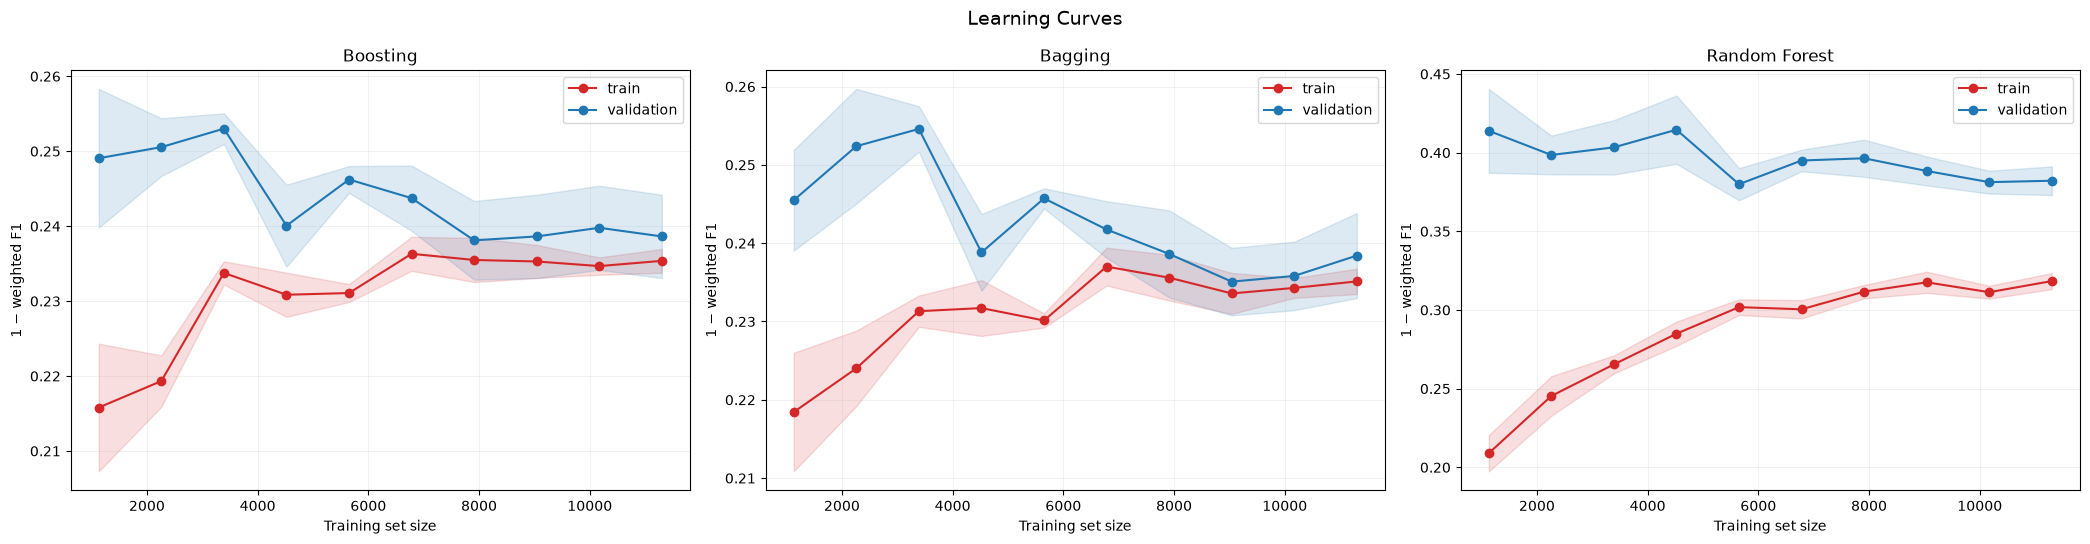

{'boosting':    train_fraction  train_size  train_error_mean  train_error_std  \
 0             0.1        1130          0.215801         0.008520   
 1             0.2        2260          0.219329         0.003433   
 2             0.3        3390          0.233760         0.001552   
 3             0.4        4521          0.230848         0.002950   
 4             0.5        5651          0.231076         0.001195   
 5             0.6        6781          0.236310         0.002271   
 6             0.7        7911          0.235488         0.002949   
 7             0.8        9042          0.235288         0.002204   
 8             0.9       10172          0.234672         0.001165   
 9             1.0       11302          0.235371         0.001593   
 
    validation_error_mean  validation_error_std  
 0               0.249065              0.009248  
 1               0.250546              0.003848  
 2               0.253010              0.002051  
 3               0.240062  

In [3]:
plot_learning_curves(
    candidates,
    "Learning Curves",
    features=X_development,
    labels=y_development,
    sample_weight=w_development,
    cv=cv,
    train_sizes=TRAIN_SIZES,
    class_labels=CLASS_LABELS,
    positive_label=1,
    scoring=STAGE_SCORING,
    random_state=RANDOM_STATE,
    show_progress=True,
)

## Feature Importance

- **Purpose:** Apply the same estimator-aware MDI, MDA, and SFI methods to each family’s best candidate.
- **Settings:** `cv=5`; `pct_embargo=0.01`; `random_state=42`; `top_k=15`; MDI/MDA/SFI in one row per family; MDA and SFI use weighted F1.
- **Data:** Calculate importance for all 52 meta features: 50 primary features plus primary side and confidence.
- **Findings:**
- **Decision:** Treat importance as a diagnostic rather than feature selection.

MDI importance:   0%|          | 0/6 [00:00<?, ?it/s]

MDA importance:   0%|          | 0/265 [00:00<?, ?it/s]

SFI importance:   0%|          | 0/265 [00:00<?, ?it/s]

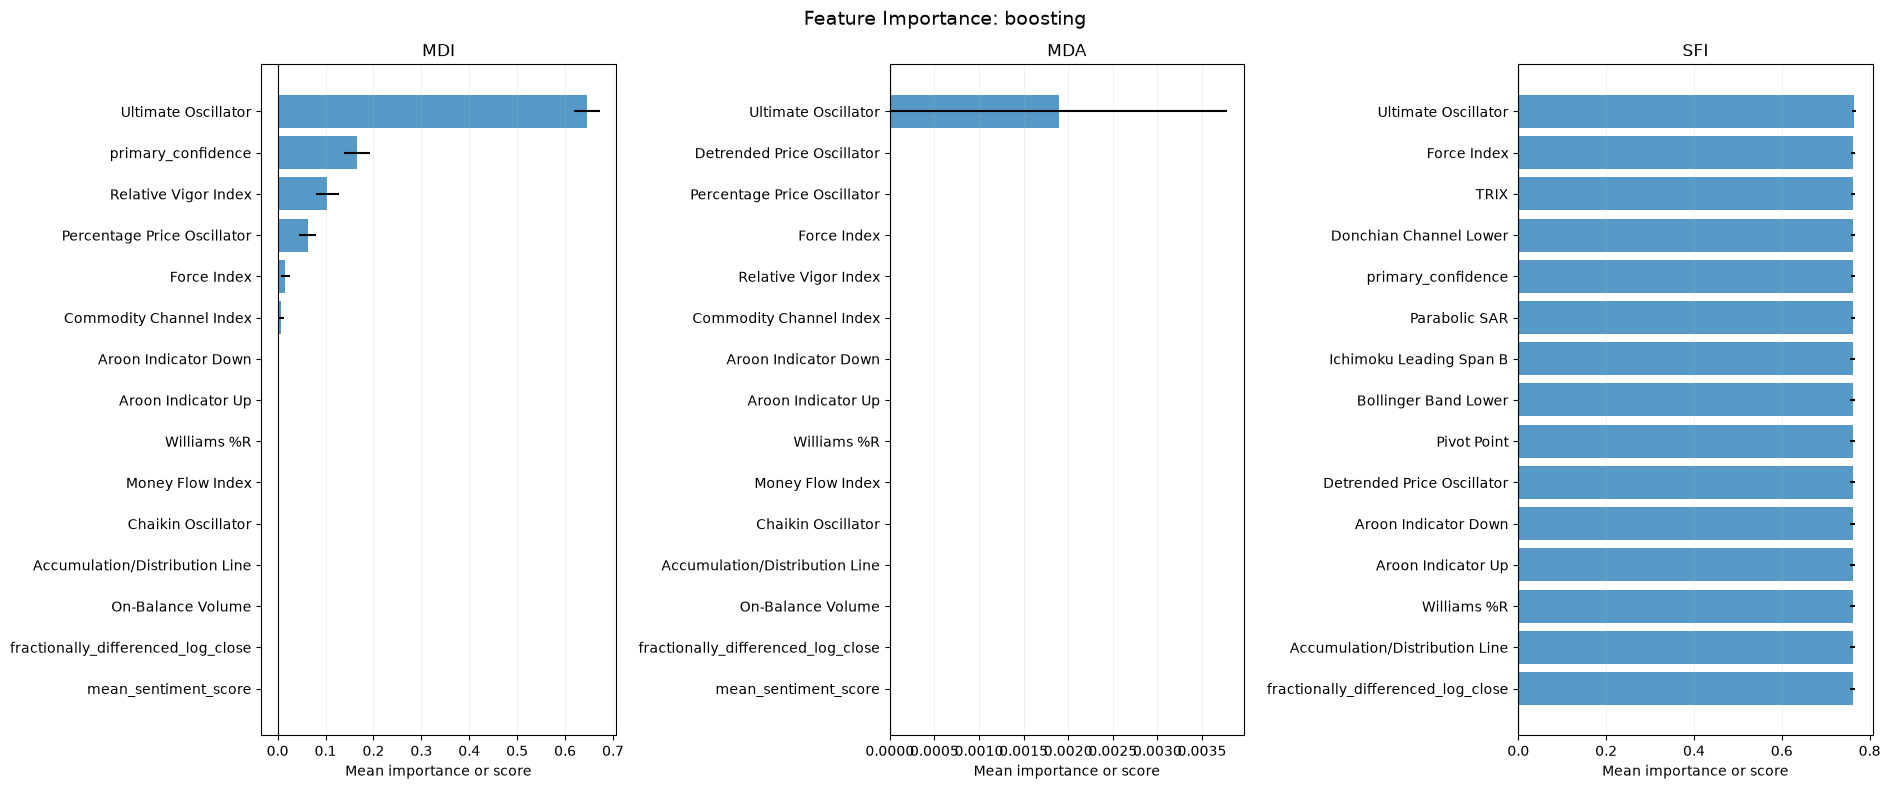

,mdi,mda,sfi_f1
Ultimate Oscillator,0.645249,0.001895,0.764323
mean_sentiment_score,0.000000,0.000000,0.759753
Bollinger Band Upper,0.000000,0.000000,0.760985
Double Exponential Moving Average (DEMA),0.000000,0.000000,0.760985
TRIX,0.000000,0.000000,0.761975
Triangular Moving Average,0.000000,0.000000,0.760985
Weighted Moving Average (WMA),0.000000,0.000000,0.760985
Hull Moving Average (HMA),0.000000,0.000000,0.760985
Volume Weighted Average Price (VWAP),0.000000,0.000000,0.760985
Parabolic SAR,0.000000,0.000000,0.761092


MDI importance:   0%|          | 0/6 [00:00<?, ?it/s]

MDA importance:   0%|          | 0/265 [00:00<?, ?it/s]

SFI importance:   0%|          | 0/265 [00:00<?, ?it/s]

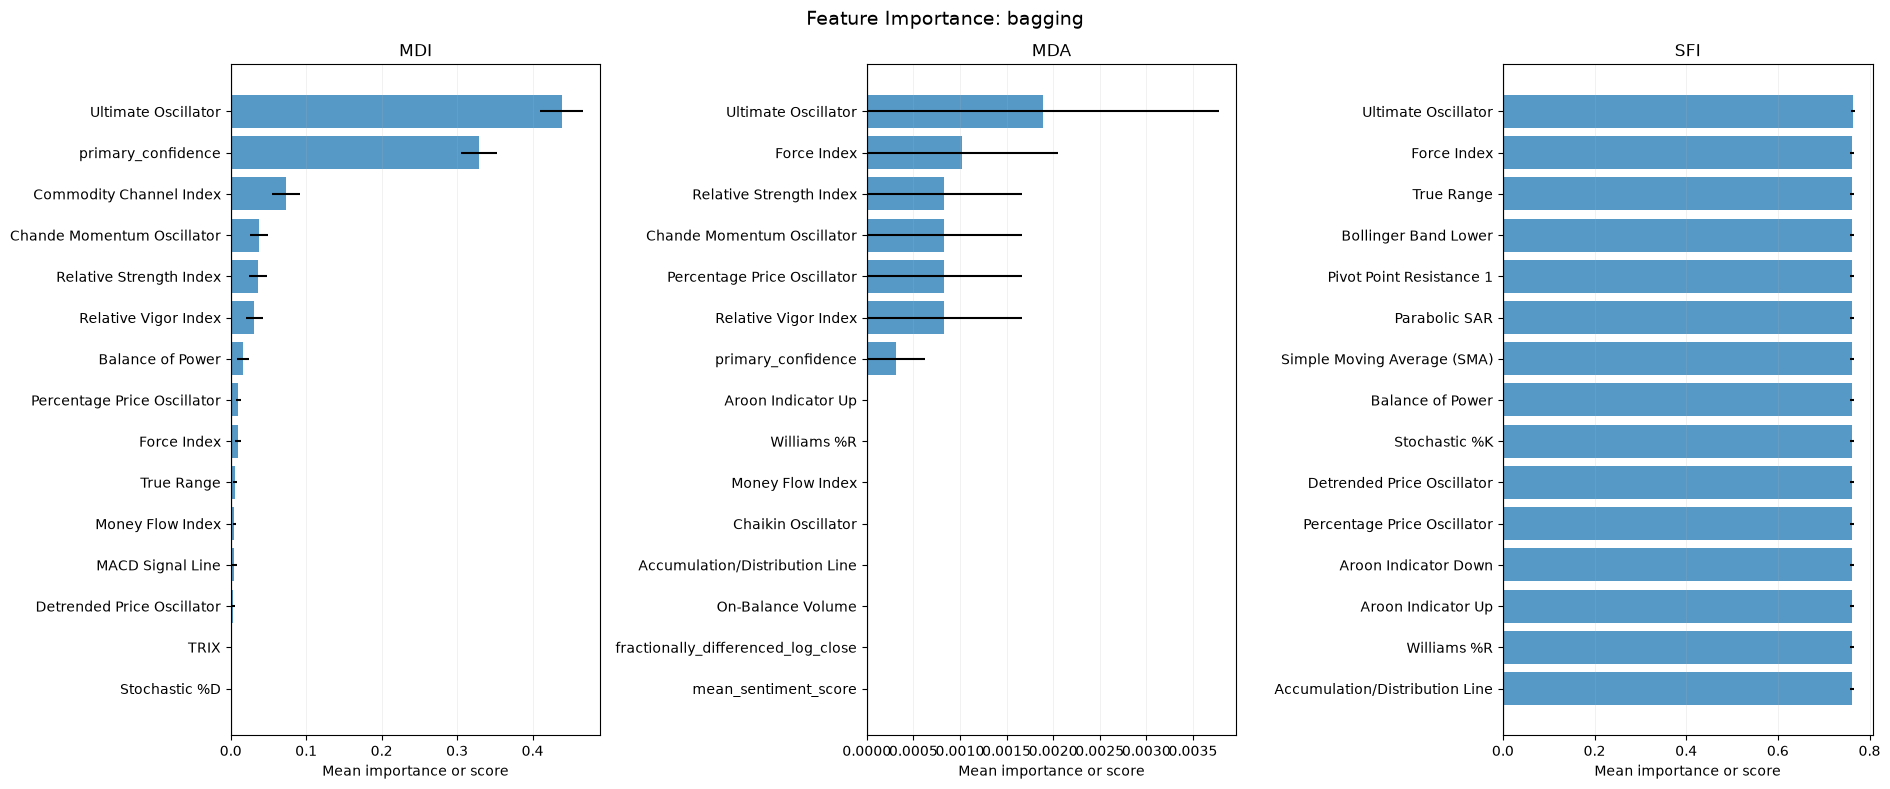

,mdi,mda,sfi_f1
Ultimate Oscillator,4.385120e-01,0.001889,0.764323
Force Index,9.345714e-03,0.001025,0.762710
Chande Momentum Oscillator,3.778748e-02,0.000832,0.760332
Relative Vigor Index,3.122537e-02,0.000832,0.758853
Percentage Price Oscillator,9.841468e-03,0.000832,0.760985
Relative Strength Index,3.588188e-02,0.000832,0.760332
primary_confidence,3.287337e-01,0.000314,0.760827
Parabolic SAR,0.000000e+00,0.000000,0.760988
Bollinger Band Middle,0.000000e+00,0.000000,0.760985
Pivot Point Resistance 1,0.000000e+00,0.000000,0.760988


MDI importance:   0%|          | 0/6 [00:00<?, ?it/s]

MDA importance:   0%|          | 0/265 [00:00<?, ?it/s]

SFI importance:   0%|          | 0/265 [00:00<?, ?it/s]

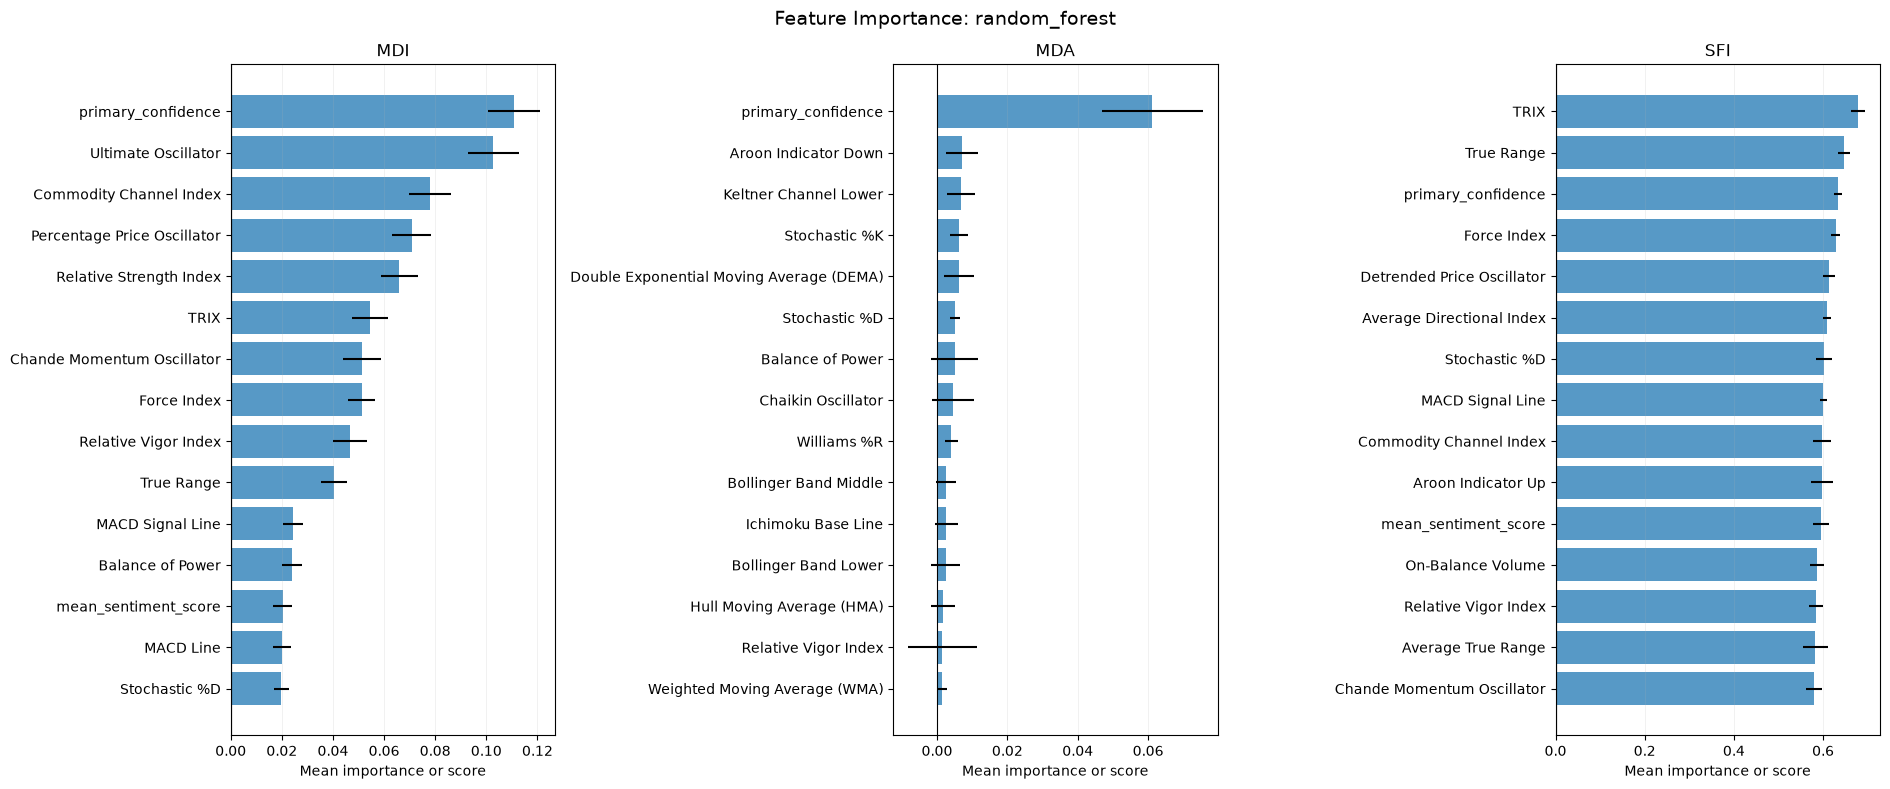

,mdi,mda,sfi_f1
primary_confidence,0.110832,0.061187,0.633444
Aroon Indicator Down,0.003087,0.007097,0.575064
Keltner Channel Lower,0.004688,0.006850,0.544900
Stochastic %K,0.012956,0.006326,0.525924
Double Exponential Moving Average (DEMA),0.002973,0.006273,0.553598
Stochastic %D,0.019776,0.005184,0.602583
Balance of Power,0.023928,0.004997,0.571671
Chaikin Oscillator,0.015589,0.004539,0.450029
Williams %R,0.009602,0.004089,0.525924
Bollinger Band Middle,0.002732,0.002681,0.528981


,boosting,bagging,random_forest
MDI,0.761371,0.761581,0.617846
MDA,0.761371,0.761581,0.617846
SFI,0.761371,0.761581,0.617846


In [4]:
importance_scores = {}
for name, estimator in candidates.items():
    results, scores = compute_stage_importance(
        estimator,
        features=X_development,
        labels=y_development,
        sample_weight=w_development,
        information_sets=t1_development,
        scoring=STAGE_SCORING,
        cv=CV_SPLITS,
        pct_embargo=PCT_EMBARGO,
        random_state=RANDOM_STATE,
        show_progress=True,
    )
    importance_scores[name] = scores
    plot_feature_importance(results, f"Feature Importance: {name}")
    importance = pd.DataFrame({
        "mdi": results["MDI"]["mean"],
        "mda": results["MDA"]["mean"],
        "sfi_f1": results["SFI"]["mean"],
    }).sort_values("mda", ascending=False)
    display(importance.head(15))
display(pd.DataFrame(importance_scores))


## Model Evaluation

- **Purpose:** Compare each family’s best candidate’s accuracy, precision, recall, F1, log loss, and diagnostic curves on development OOF predictions; confusion matrices in one row and overlaid PR/ROC side by side.
- **Settings:** Labels = {0, 1}; positive label = 1; sample-weighted metrics, confusion matrices, PR/AP and ROC/AUC.
- **Data:** Use development OOF results, then persist the model and prediction provenance.
- **Findings:**
- **Decision:** Fix the configuration from development OOF; holdout predictions are saved without displaying holdout evaluation.

,accuracy,precision,recall,f1,log_loss
model,,,,,
Boosting,0.615959,0.615635,1.000000,0.762096,0.682926
Bagging,0.616350,0.615876,1.000000,0.762281,0.660167
Random Forest,0.562165,0.666559,0.576693,0.618378,0.685675


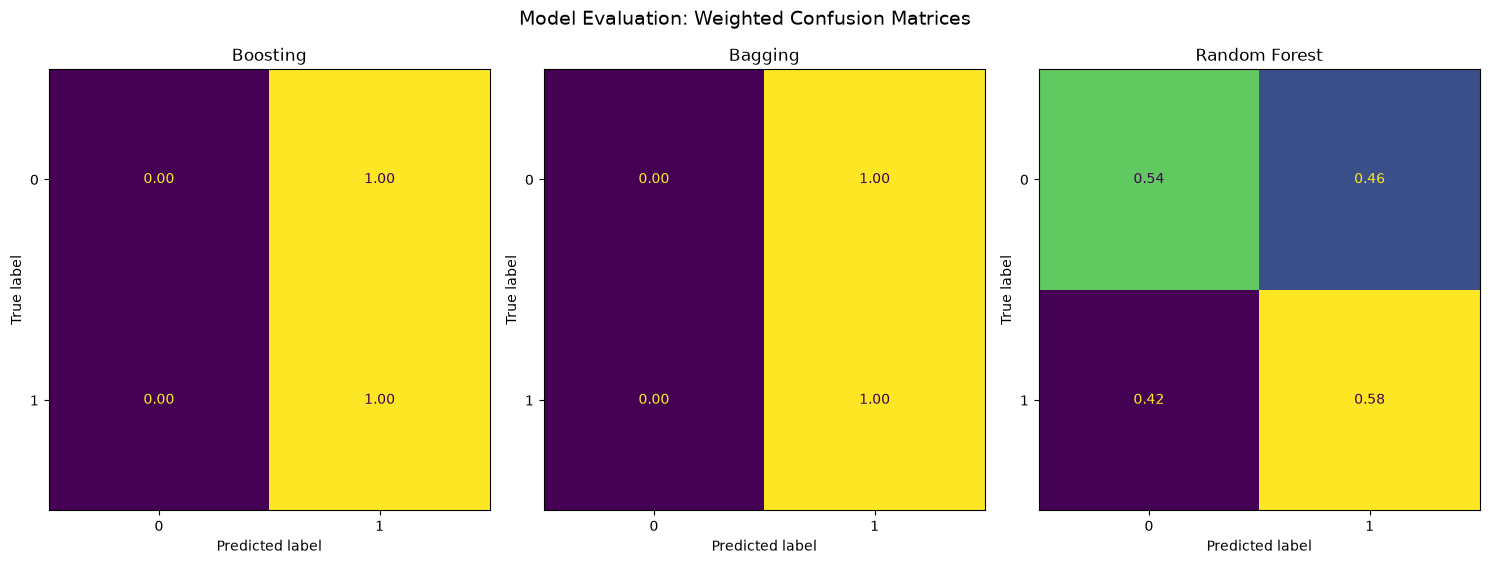

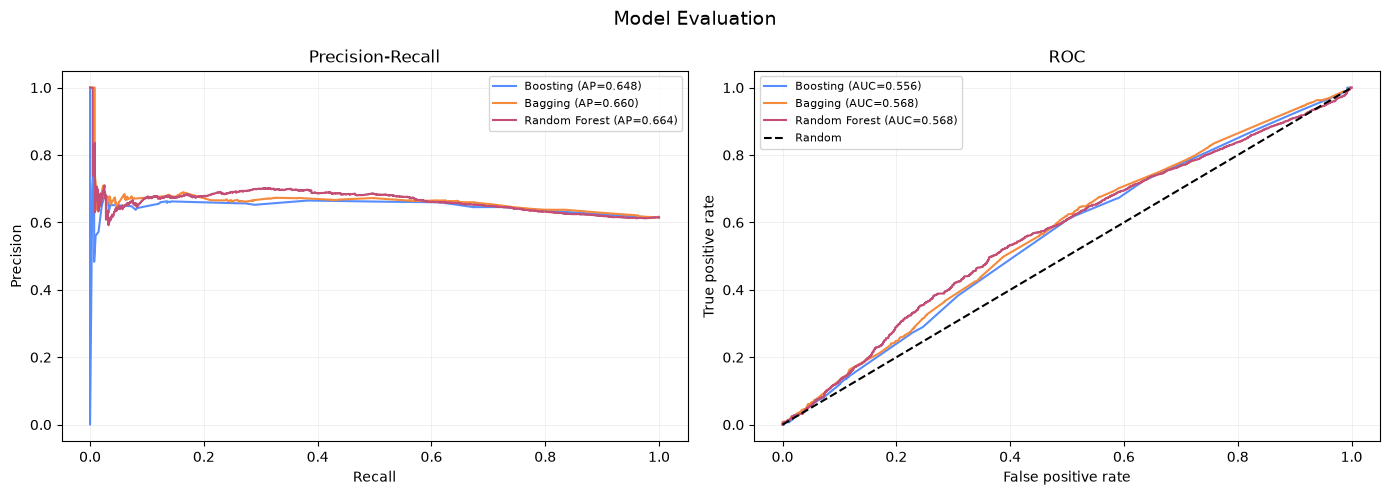

Final meta model:   0%|          | 0/4 [00:00<?, ?it/s]

/Users/kwonjunhyuk9/Documents/financial-machine-learning/data/modeling/sentiment/meta_model.joblib


In [5]:
display(build_model_evaluation_table(
    candidate_oof,
    y_development,
    w_development,
    class_labels=CLASS_LABELS,
    positive_label=1,
))

plot_model_evaluation(
    candidate_oof,
    y_development,
    w_development,
    "Model Evaluation",
    class_labels=CLASS_LABELS,
    positive_label=1,
)
meta_predictions = finalize_meta_model(
    meta_development,
    events,
    primary_predictions,
    estimator=final_estimator,
    final_oof=final_oof,
    feature_columns=meta_features,
    artifact_dir=artifact_dir,
    selected_candidate=final_name,
    best_configuration=final_configuration,
    random_state=RANDOM_STATE,
    show_progress=True,
)

print(artifact_dir / "meta_model.joblib")